In [17]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 14.6 MB/s eta 0:00:00


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

[*********************100%***********************]  1 of 1 completed

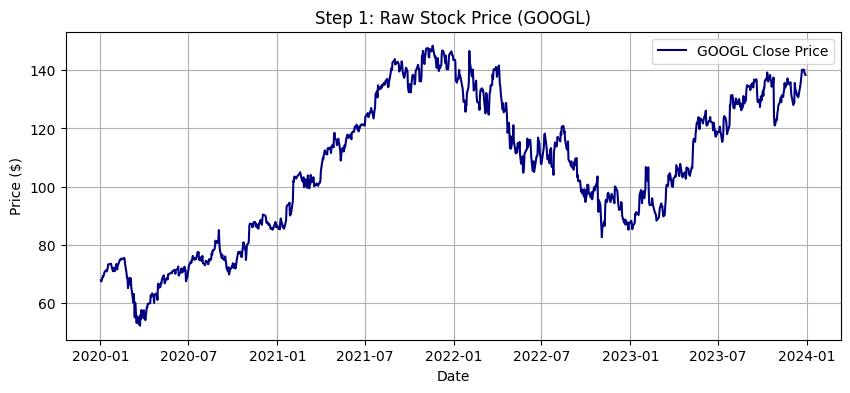

In [19]:
# ==============================================================================
# STEP 1: CHOOSE DATA SOURCE AND LOAD THE DATA
# ==============================================================================
# You can switch between "yfinance" (downloads from internet) and "csv" (local file).

DATA_SOURCE = "yfinance"  # Options: "yfinance" OR "csv"
CSV_FILE_PATH = "google_stock.csv"  # File path if using CSV
TICKER = "GOOGL"                    # Stock symbol
START_DATE = "2020-01-01"
END_DATE = "2023-12-31"

def load_data(source, ticker, csv_path, start, end):
    # Instruction: If user chose 'yfinance', download stock data directly.
    if source == "yfinance":
        import yfinance as yf
        print(f"Downloading data for {ticker} from Yahoo Finance...")
        df = yf.download(ticker, start=start, end=end)

        # Handle recent yfinance multi-index column output
        if isinstance(df.columns, pd.MultiIndex):
            df = df['Close']
            df.columns = [ticker]
        else:
            df = df[['Close']].rename(columns={'Close': ticker})

    # Instruction: If user chose 'csv', read from local file.
    elif source == "csv":
        print(f"Loading data from CSV file: {csv_path}...")
        df = pd.read_csv(csv_path, parse_dates=['Date'], index_col='Date')
        # Rename the first price column to match our ticker variable
        price_col = df.columns[0]
        df = df[[price_col]].rename(columns={price_col: ticker})
    else:
        raise ValueError("Invalid source! Pick either 'yfinance' or 'csv'.")

    return df.dropna()

# Load the data into a dataframe
df = load_data(DATA_SOURCE, TICKER, CSV_FILE_PATH, START_DATE, END_DATE)
price_series = df[TICKER]

# Plot original stock prices
plt.figure(figsize=(10, 4))
plt.plot(price_series, color='navy', label=f"{TICKER} Close Price")
plt.title(f"Step 1: Raw Stock Price ({TICKER})")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()


--- Running ADF Stationarity Test for: Raw Stock Price ---
ADF Statistic: -1.5208
p-value:       0.5232
Result: Raw Stock Price is NOT Stationary (p-value > 0.05). Needs differencing!

--- Running ADF Stationarity Test for: Log Returns (1st Difference) ---
ADF Statistic: -10.2747
p-value:       0.0000
Result: Log Returns (1st Difference) IS Stationary (p-value <= 0.05). Ready for ARIMA!


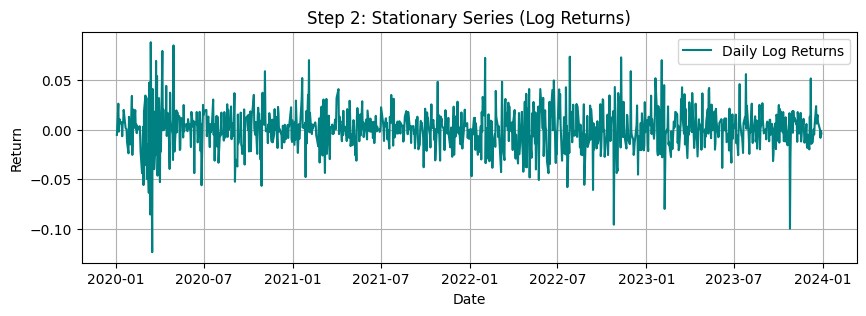

In [20]:
# ==============================================================================
# STEP 2: CHECK STATIONARITY (ADF TEST) & TRANSFORM DATA
# ==============================================================================
# Explanation: Stock prices go up/down over time (Non-Stationary).
# ARIMA requires the data to be Stationary (mean & variance stay steady).
# We use the Augmented Dickey-Fuller (ADF) test to verify this mathematically.

def run_adf_test(series, series_name):
    print(f"\n--- Running ADF Stationarity Test for: {series_name} ---")
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {p_value:.4f}")

    # Simple Rule: p-value <= 0.05 means stationary. > 0.05 means non-stationary.
    if p_value <= 0.05:
        print(f"Result: {series_name} IS Stationary (p-value <= 0.05). Ready for ARIMA!")
    else:
        print(f"Result: {series_name} is NOT Stationary (p-value > 0.05). Needs differencing!")

# Test raw price series
run_adf_test(price_series, "Raw Stock Price")

# Calculate Daily Log Returns (First Differencing on log scale)
df['Log_Return'] = np.log(price_series / price_series.shift(1))
log_returns = df['Log_Return'].dropna()

# Test daily log returns
run_adf_test(log_returns, "Log Returns (1st Difference)")

# Plot Log Returns
plt.figure(figsize=(10, 3))
plt.plot(log_returns, color='teal', label="Daily Log Returns")
plt.title("Step 2: Stationary Series (Log Returns)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# ==============================================================================
# STEP 3: SPLIT DATA INTO TRAIN AND TEST SETS
# ==============================================================================
# Explanation: We use 80% of historical data to train the model,
# and keep 20% secret to test how well our forecasts match real future prices.

train_size = int(len(price_series) * 0.8)
train = price_series.iloc[:train_size]
test = price_series.iloc[train_size:]

print(f"\nData Split Completed:")
print(f"Training observations: {len(train)}")
print(f"Testing observations:  {len(test)}")


Data Split Completed:
Training observations: 804
Testing observations:  202


In [22]:
# ==============================================================================
# STEP 4: MODEL IDENTIFICATION & SELECTION (AUTO-ARIMA)
# ==============================================================================
# Explanation: ARIMA has 3 parameters -> (p, d, q)
# p = Auto-Regressive order
# d = Differencing degree (d=1 converts prices into stationary returns)
# q = Moving Average order
# auto_arima tests multiple combinations and picks the one with lowest AIC score.

print("\n--- Searching for Best ARIMA(p, d, q) Parameters ---")
best_model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,                # Force d=1 because stock prices are integrated I(1)
    seasonal=False,     # Daily stock data usually does not have fixed seasonality
    stepwise=True,      # Faster search algorithm
    trace=True,         # Show trial process in console
    suppress_warnings=True
)

# Extract optimal parameters
p, d, q = best_model.order
print(f"\nBest Selected Model Order: ARIMA({p}, {d}, {q})")


--- Searching for Best ARIMA(p, d, q) Parameters ---
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3501.695, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3499.956, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3499.916, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3499.833, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3500.575, Time=0.56 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.830 seconds

Best Selected Model Order: ARIMA(0, 1, 0)


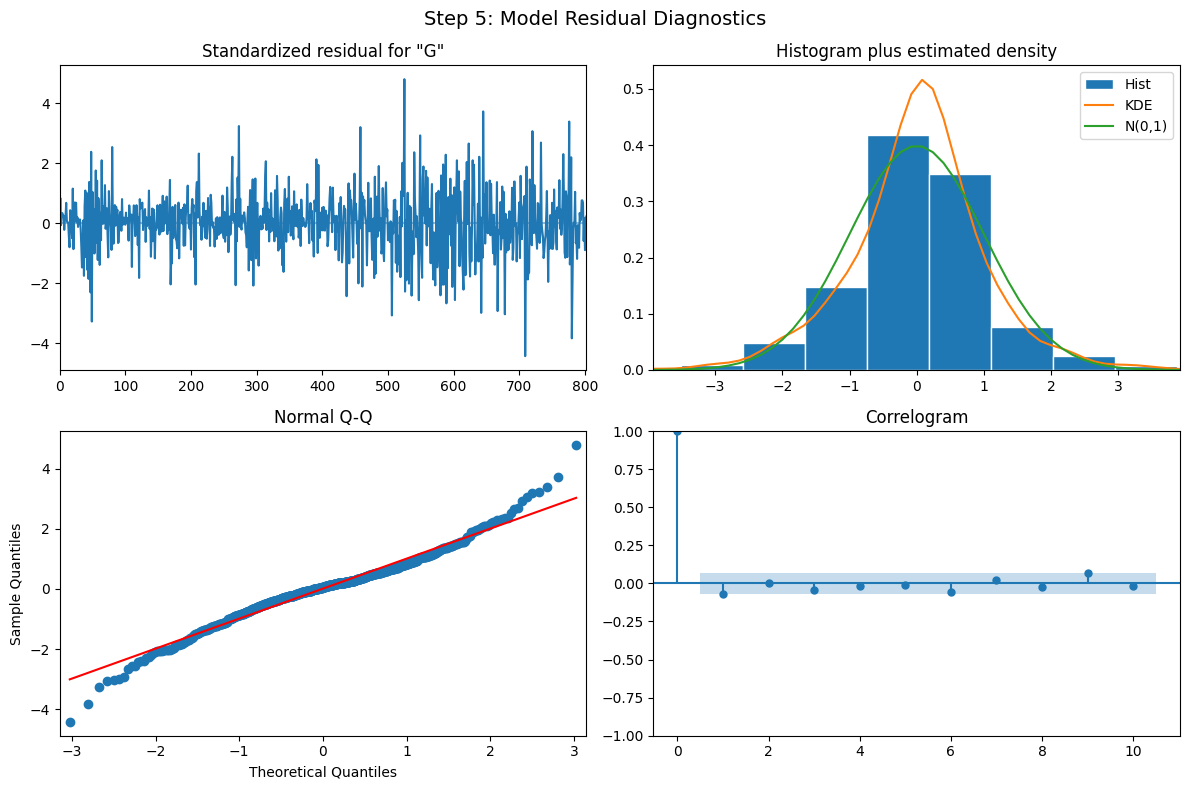


--- Ljung-Box Residual Autocorrelation Test ---
     lb_stat  lb_pvalue
10  3.060935   0.979953
20  6.622543   0.997752
Diagnostics Passed: Errors are random White Noise (No missed patterns).


In [23]:
# ==============================================================================
# STEP 5: FIT THE MODEL & CHECK RESIDUAL DIAGNOSTICS
# ==============================================================================
# Explanation: A good ARIMA model leaves behind only random noise ("White Noise").
# If pattern remains in the error (residuals), the model is bad.

# Fit the optimal ARIMA model on training data
fitted_arima = sm.tsa.ARIMA(train, order=(p, d, q)).fit()

# Plot Diagnostic Charts (Standardized Residuals, Histogram, QQ Plot, ACF)
fitted_arima.plot_diagnostics(figsize=(12, 8))
plt.suptitle("Step 5: Model Residual Diagnostics", fontsize=14)
plt.tight_layout()
plt.show()

# Run Ljung-Box Test on Residuals
# Rule: If p-value > 0.05, residuals are pure white noise (Model is valid!)
lb_test = acorr_ljungbox(fitted_arima.resid, lags=[10, 20], return_df=True)
print("\n--- Ljung-Box Residual Autocorrelation Test ---")
print(lb_test)

if (lb_test['lb_pvalue'] > 0.05).all():
    print("Diagnostics Passed: Errors are random White Noise (No missed patterns).")
else:
    print("Diagnostics Warning: Autocorrelation present in errors.")

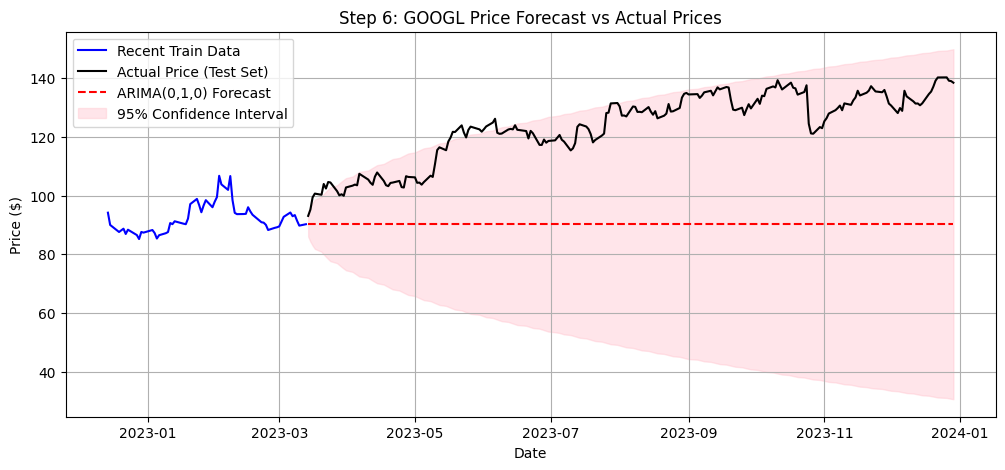


--- Forecast Error Metrics ---
Root Mean Squared Error (RMSE): $35.20
Mean Absolute Error     (MAE):  $33.19


In [25]:
# ==============================================================================
# STEP 6: OUT-OF-SAMPLE FORECASTING & ACCURACY EVALUATION
# ==============================================================================
# Explanation: Generate future predictions for the test period and compare
# them with actual prices using metric tools like RMSE and MAE.

# Generate forecasts for test length
forecast_out = fitted_arima.get_forecast(steps=len(test), index=test.index)
forecast_mean = forecast_out.predicted_mean
confidence_intervals = forecast_out.conf_int(alpha=0.05)  # 95% Confidence Level

# Match index dates with test set
forecast_series = pd.Series(forecast_mean.values, index=test.index)
lower_bound = pd.Series(confidence_intervals.iloc[:, 0].values, index=test.index)
upper_bound = pd.Series(confidence_intervals.iloc[:, 1].values, index=test.index)

# Plot Forecast vs Actual
plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train.values[-60:], label="Recent Train Data", color='blue')
plt.plot(test.index, test.values, label="Actual Price (Test Set)", color='black')
plt.plot(forecast_series.index, forecast_series.values, label=f"ARIMA({p},{d},{q}) Forecast", color='red', linestyle='--')
plt.fill_between(test.index, lower_bound, upper_bound, color='pink', alpha=0.4, label="95% Confidence Interval")

plt.title(f"Step 6: {TICKER} Price Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# Calculate Performance Metrics
rmse = np.sqrt(mean_squared_error(test, forecast_series))
mae = mean_absolute_error(test, forecast_series)

print("\n--- Forecast Error Metrics ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error     (MAE):  ${mae:.2f}")